In [30]:
import numpy as np
import harmonica as hm
import choclo
import bordado as bd
import numba
import boule as bl
import verde as vd
import matplotlib.pyplot as plt
import spherical as sph

In [31]:
CM = choclo.constants.VACUUM_MAGNETIC_PERMEABILITY / 4 / np.pi


def dipole_magnetic_spherical(geodetic_coordinates, geodetic_dipoles, magnetic_moments):
    """
    Calculate the magnetic field of dipoles in spherical coordinates

    Input coordinates are geocentric spherical and the output vector is in
    a local north-oriented Cartesian frame with the z-axis aligned with the
    radial direction.

    Parameters
    ----------
    coordinates : tuple of arrays
        Tuple of arrays containing the longitude, spherical latitude, and
        radius coordinates of the computation points defined on a geocentric
        spherical coordinate system. Longitude and latitude should be in
        decimal degrees and radius should be in meters. Coordinates can be
        n-dimensional arrays but all arrays must have the same shape.
    dipoles: tuple of arrays
        Tuple of arrays containing the longitude, spherical latitude, and
        radius coordinates of the dipoles defined on a geocentric spherical
        coordinate system. Longitude and latitude should be in decimal degrees
        and radius should be in meters. Coordinates can be n-dimensional arrays
        but all arrays must have the same shape.
    magnetic_moments: tuple of arrays
        Tuple of arrays containing the magnetic moments of the dipoles, given
        by three components: longitudinal, latitudinal, and radial. Each
        component should be an n-dimensional array with the same shape as the
        dipole coordinates. The vector components are defined on a local
        north-oriented Cartesian system located at the dipole.

    Returns:
    - B_r (array): Magnetic field component in the radial direction (nT) at each observation point.
    - B_colat (array): Magnetic field component in the theta direction (nT) at each observation point.
    - B_lon (array): Magnetic field component in the phi direction (nT) at each observation point.

    This function:
    1. Converts latitude and longitude from degrees to radians for spherical coordinate calculations.
    2. Calculates directional cosines and separation distances between source and observation points.
    3. Computes intermediate matrices (H_ij) accounting for the geometry and separation between source and observation points.
    4. Uses the magnetic moments and geometry to compute the magnetic field components in spherical coordinates.

    Notes:
    - The magnetic field components are returned in nanotesla (nT).
    - The constant CM (not passed as an argument) is used to scale the magnetic field based on the source-observation geometry.

    The function assumes that the magnetic field is modeled by the superposition of dipoles with specified magnetic moments.
    Each dipole is characterized by its position in spherical coordinates (longitude, latitude, radius) and its magnetic moment components.
    """
    geodetic_coordinates = bd.check_coordinates(geodetic_coordinates)
    geodetic_dipoles = bd.check_coordinates(geodetic_dipoles)
    magnetic_moments = bd.check_coordinates(magnetic_moments)

    coordinates = bl.WGS84.geodetic_to_spherical(geodetic_coordinates[0], geodetic_coordinates[1], geodetic_coordinates[2])
    dipoles = bl.WGS84.geodetic_to_spherical(geodetic_dipoles[0], geodetic_dipoles[1], geodetic_dipoles[2])
    print(coordinates)
    print(dipoles)

    
    # Convert to 1D arrays to make it easier to loop over them
    shape = coordinates[0].shape
    n_data = coordinates[0].size
    coordinates = tuple(c.ravel() for c in coordinates)
    dipoles = tuple(c.ravel() for c in dipoles)
    magnetic_moments = tuple(c.ravel() for c in magnetic_moments)

    b_lon = np.zeros(n_data)
    b_lat = np.zeros(n_data)
    b_radial = np.zeros(n_data)
    _dipole_magnetic_spherical_fast(
        np.radians(coordinates[0]),
        np.radians(90 - coordinates[1]),
        coordinates[2],
        np.radians(dipoles[0]),
        np.radians(90 - dipoles[1]),
        dipoles[2],
        magnetic_moments[0],
        magnetic_moments[1],
        magnetic_moments[2],
        b_lon,
        b_lat,
        b_radial,
    )

    b_lon, b_lat, b_radial = spherical_to_geodetic(coordinates[1], geodetic_coordinates[1], b_lat, b_lon, b_radial)

    # Rename things back to the original coordinate shapes
    b_lon = b_lon.reshape(shape)
    b_lat = b_lat.reshape(shape)
    b_radial = b_radial.reshape(shape)

    return b_lon, b_lat, b_radial


@numba.jit(nopython=True, parallel=True)
def _dipole_magnetic_spherical_fast(
    longitude,
    colatitude,
    radius,
    longitude_d,
    colatitude_d,
    radius_d,
    m_lon,
    m_colat,
    m_radial,
    b_lon,
    b_lat,
    b_radial,
):
    n_dipoles = longitude_d.size
    n_data = longitude.size
    for j in numba.prange(n_dipoles):
        sin_colat_d = np.sin(colatitude_d[j])
        cos_colat_d = np.cos(colatitude_d[j])
        for i in range(n_data):
            sin_colat = np.sin(colatitude[i])
            cos_colat = np.cos(colatitude[i])
            sin_lon = np.sin(longitude[i] - longitude_d[j])
            cos_lon = np.cos(longitude[i] - longitude_d[j])
            b_lon_j, b_lat_j, b_radial_j = _kernel(
                cos_lon,
                sin_lon,
                cos_colat,
                sin_colat,
                radius[i],
                cos_colat_d,
                sin_colat_d,
                radius_d[j],
                m_lon[j],
                m_colat[j],
                m_radial[j],
            )
            b_lon[i] += b_lon_j
            b_lat[i] += b_lat_j
            b_radial[i] += b_radial_j


@numba.jit(nopython=True)
def _kernel(
    cos_lon,
    sin_lon,
    cos_colat,
    sin_colat,
    radius,
    cos_colat_d,
    sin_colat_d,
    radius_d,
    m_lon,
    m_colat,
    m_radial,
):
    """
    Just the forward modeling kernel equations.
    """
    mu_ij = cos_colat * cos_colat_d + sin_colat * sin_colat_d * cos_lon
    ri_dot_thetaj = -cos_colat * sin_colat_d + sin_colat * cos_colat_d * cos_lon
    ri_dot_phij = sin_colat * sin_lon
    thetai_dot_rj = -sin_colat * cos_colat_d + cos_colat * sin_colat_d * cos_lon
    thetai_dot_thetaj = sin_colat * sin_colat_d + cos_colat * cos_colat_d * cos_lon
    thetai_dot_phij = cos_colat * sin_lon
    phii_dot_rj = -sin_colat_d * sin_lon
    phii_dot_thetaj = -cos_colat_d * sin_lon
    phii_dot_phij = cos_lon

    # Distance r_ij between the computation point and the dipole
    r_ij = np.sqrt((radius**2) + (radius_d**2) - 2 * radius * radius_d * mu_ij)
    r_ij2 = r_ij**2

    # Define magnetic field terms
    CM_rij3 = CM / r_ij**3
    H_11 = CM_rij3 * (
        3 * ((radius - radius_d * mu_ij) * (radius * mu_ij - radius_d) / r_ij2) - mu_ij
    )
    H_12 = CM_rij3 * (
        3 * ((radius - radius_d * mu_ij) * (radius * ri_dot_thetaj) / r_ij2)
        - ri_dot_thetaj
    )
    H_13 = CM_rij3 * (
        3 * ((radius - radius_d * mu_ij) * (radius * ri_dot_phij) / r_ij2) - ri_dot_phij
    )
    H_21 = -CM_rij3 * (
        3 * ((radius_d * thetai_dot_rj) * (radius * mu_ij - radius_d) / r_ij2)
        + thetai_dot_rj
    )
    H_22 = -CM_rij3 * (
        3 * ((radius_d * thetai_dot_rj) * (radius * ri_dot_thetaj) / r_ij2)
        + thetai_dot_thetaj
    )
    H_23 = -CM_rij3 * (
        3 * ((radius_d * thetai_dot_rj) * (radius * ri_dot_phij) / r_ij2)
        + thetai_dot_phij
    )
    H_31 = -CM_rij3 * (
        3 * ((radius_d * phii_dot_rj) * (radius * mu_ij - radius_d) / r_ij2)
        + phii_dot_rj
    )
    H_32 = -CM_rij3 * (
        3 * ((radius_d * phii_dot_rj) * (radius * ri_dot_thetaj) / r_ij2)
        + phii_dot_thetaj
    )
    H_33 = -CM_rij3 * (
        3 * ((radius_d * phii_dot_rj * radius * ri_dot_phij) / r_ij2) + phii_dot_phij
    )

    # Convert the magnetic moment to the local Cartesian system of the
    # observation point P.
    m_radial_p = m_radial * mu_ij + m_colat * ri_dot_thetaj + m_lon * ri_dot_phij
    m_colat_p = (
        m_radial * thetai_dot_rj + m_colat * thetai_dot_thetaj + m_lon * thetai_dot_phij
    )
    m_lon_p = m_radial * phii_dot_rj + m_colat * phii_dot_thetaj + m_lon * phii_dot_phij

    # Calculate final magnetic field components and convert them from T to nT
    b_lon = (H_31 * m_radial_p + H_32 * m_colat_p + H_33 * m_lon_p) * 1e9
    # The - converts colatitude to latitude.
    b_lat = -(H_21 * m_radial_p + H_22 * m_colat_p + H_23 * m_lon_p) * 1e9
    b_radial = (H_11 * m_radial_p + H_12 * m_colat_p + H_13 * m_lon_p) * 1e9

    return b_lon, b_lat, b_radial


def jacobian(
    coordinates,
    dipoles,
    inclination_source,
    declination_souce,
    inclination_field,
    declination_field,
):
    coordinates = bd.check_coordinates(coordinates)
    dipoles = bd.check_coordinates(dipoles)
    coordinates = tuple(c.ravel() for c in coordinates)
    dipoles = tuple(c.ravel() for c in dipoles)
    n_data = coordinates[0].size
    n_params = dipoles[0].size

    unit_magnetic_moment = hm.magnetic_angles_to_vec(
        1, inclination_source, declination_souce
    )
    main_field =  hm.magnetic_angles_to_vec(
        1, inclination_field, declination_field
    )

    A = np.empty((n_data, n_params))
    _jacobian_fast(
        np.radians(coordinates[0]),
        np.radians(90 - coordinates[1]),
        coordinates[2],
        np.radians(dipoles[0]),
        np.radians(90 - dipoles[1]),
        dipoles[2],
        unit_magnetic_moment[0],
        unit_magnetic_moment[1],
        unit_magnetic_moment[2],
        main_field[0],
        main_field[1],
        main_field[2],
        A,
    )

    return A


@numba.jit(nopython=True, parallel=True)
def _jacobian_fast(
    longitude,
    colatitude,
    radius,
    longitude_d,
    colatitude_d,
    radius_d,
    m_lon,
    m_colat,
    m_radial,
    f_lon,
    f_lat,
    f_radial,
    A,
):
    n_dipoles = longitude_d.size
    n_data = longitude.size
    for j in numba.prange(n_dipoles):
        sin_colat_d = np.sin(colatitude_d[j])
        cos_colat_d = np.cos(colatitude_d[j])
        for i in range(n_data):
            sin_colat = np.sin(colatitude[i])
            cos_colat = np.cos(colatitude[i])
            sin_lon = np.sin(longitude[i] - longitude_d[j])
            cos_lon = np.cos(longitude[i] - longitude_d[j])
            b_lon, b_lat, b_radial = _kernel(
                cos_lon,
                sin_lon,
                cos_colat,
                sin_colat,
                radius[i],
                cos_colat_d,
                sin_colat_d,
                radius_d[j],
                m_lon,
                m_colat,
                m_radial,
            )
            A[i, j] = f_lon * b_lon + f_lat * b_lat + f_radial * b_radial


def calculate_coefficients(observed_data, A, damping):

    I = np.identity(A.shape[1])  # needs to = m x m
    # np.shape(A) = A.shape

    # The @ operator can be used for cocalculate_total_field_anomaly(grid_coord, observed_source_coord, 0, 0, 1e17, 0, 0)nventional matrix multiplication.
    system_matrix = A.T @ A + I * damping
    system_rhs_vector = A.T @ observed_data

    coefficients = np.linalg.solve(system_matrix, system_rhs_vector)

    return coefficients


def profile_points(start, end, npoints, depth=0):
    """
    Generate evenly spaced coordinates for a profile along a great circle,
    with a fixed depth value for the entire arc.

    Both start and end should be (longitude, latitude) pairs.
    The depth parameter sets a constant depth for all points along the profile.

    Returns longitude, latitude, and depth coordinates in a format that can be
    passed to xarray.Dataset.interp.
    """
    lon1, lat1 = np.radians(start)
    lon2, lat2 = np.radians(end)

    azimuth1 = np.arctan2(
        np.cos(lat2) * np.sin(lon2 - lon1),
        np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lon2 - lon1),
    )

    azimuth_equator = np.arctan2(
        np.sin(azimuth1) * np.cos(lat1),
        np.sqrt(np.cos(azimuth1) ** 2 + np.sin(azimuth1) ** 2 * np.sin(lat1) ** 2),
    )

    great_circle_equator = np.arctan2(np.tan(lat1), np.cos(azimuth1))
    lon_equator = lon1 - np.arctan2(
        np.sin(azimuth_equator) * np.sin(great_circle_equator),
        np.cos(great_circle_equator),
    )

    great_circle_distance = 2 * np.arcsin(
        np.sqrt(
            np.sin((lat2 - lat1) / 2) ** 2
            + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
        )
    )

    distances = np.linspace(start=0, stop=great_circle_distance, num=npoints)
    distances_equator = distances + great_circle_equator

    latitudes = np.arctan2(
        np.cos(azimuth_equator) * np.sin(distances_equator),
        np.sqrt(
            np.cos(distances_equator) ** 2
            + (np.sin(azimuth_equator) * np.sin(distances_equator)) ** 2
        ),
    )

    longitudes = lon_equator + np.arctan2(
        np.sin(azimuth_equator) * np.sin(distances_equator), np.cos(distances_equator)
    )

    longitude = np.degrees(longitudes)
    latitude = np.degrees(latitudes)
    depth_array = np.full(npoints, depth)

    dike = np.array([longitude]), np.array([latitude]), np.array([depth_array])

    return dike

def geodetic_to_spherical(sph_latitude, geod_latitude):

    w11 = 1
    w12 = 0
    w13 = 0
    
    w21 = 0
    w22 = np.cos(geod_latitude-sph_latitude)
    w23 = np.sin(geod_latitude-sph_latitude)
    
    w31 = 0
    w32 = - np.sin(geod_latitude-sph_latitude)
    w33 = np.cos(geod_latitude-sph_latitude)
    
    # Construct the matrix
    w = ([[w11, w12, w13],
        [w21, w22, w23],
        [w31, w32, w33]])
    
    return w

def spherical_to_geodetic(sph_latitude, geod_latitude, b_lon, b_lat, b_radial):

    sph_latitude = np.radians(sph_latitude)
    geod_latitude = np.radians(geod_latitude)

    w11 = 1
    w12 = 0
    w13 = 0
    
    w21 = 0
    w22 = np.cos(sph_latitude-geod_latitude)
    w23 = np.sin(sph_latitude-geod_latitude)
    
    w31 = 0
    w32 = - np.sin(sph_latitude-geod_latitude)
    w33 = np.cos(sph_latitude-geod_latitude)
    
    lon_geodetic = (w11 * b_lon + w12 * b_lat + w13 * b_radial) 
    lat_geodetic = (w21 * b_lon + w22 * b_lat + w23 * b_radial) 
    radial_geodetic = (w31 * b_lon + w32 * b_lat + w33 * b_radial) 
    
    return lon_geodetic, lat_geodetic, radial_geodetic

In [32]:
region = [0, 0, 90, 90]  

# spacing_1 = (0.3, 0.2)
# coordinates = vd.grid_coordinates(region=region, spacing=spacing_1, extra_coords=481)
coordinates = vd.scatter_points(region=region, size=1, extra_coords= 0)


print("Geodetic longitude:", coordinates[0])
print("Geodetic latitude:", coordinates[1])
print("Height (m):", coordinates[2])

Geodetic longitude: [0.]
Geodetic latitude: [90.]
Height (m): [0.]


In [33]:
inclination = 45 
declination = 20
# Syntetic dipoles

dipoles = tuple(c.ravel() for c in vd.scatter_points(region= region, size= 1, extra_coords=  - 40000))
#Data

magnetic_field = sph.dipole_magnetic_spherical(coordinates,dipoles,
magnetic_moments = hm.magnetic_angles_to_vec(
    np.full(1, 1e12),  
    np.full(1, inclination),  
    np.full(1, declination)   
)
)

In [34]:
dipoles_geod = hm.total_field_anomaly(magnetic_field, inclination, declination)

In [35]:
ellipsoid = bl.WGS84

spacing_1 = (0.3, 0.2) 
# coordinates = vd.grid_coordinates(region=region, spacing=spacing_1, extra_coords=481)
coordinates = vd.scatter_points(region=region, size=1, extra_coords=ellipsoid.semimajor_axis)

print("Longitude:", coordinates[0])
print("Latitude:", coordinates[1])
print("Height (m):", coordinates[2])

Longitude: [0.]
Latitude: [90.]
Height (m): [6378137.]


In [36]:
# Syntetic dipoles

dipoles = tuple(c.ravel() for c in vd.scatter_points(region= region, size= 1, extra_coords= ellipsoid.semimajor_axis  - 40000))
#Data

magnetic_field = sph.dipole_magnetic_spherical(coordinates,dipoles,
magnetic_moments = hm.magnetic_angles_to_vec(
    np.full(1, 1e12),  
    np.full(1, inclination),  
    np.full(1, declination)   
)
)

In [37]:
dipoles = hm.total_field_anomaly(magnetic_field, inclination, declination)

In [38]:
print(dipoles_geod, dipoles)

[2.16097222] [2.16097222]


In [39]:
a = spherical_to_geodetic(0,0, 1,0,0)

print(a)

(1, np.float64(0.0), np.float64(0.0))


In [40]:
def angular_distance(vec_a, vec_b):
    vec_a = vec_a
    vec_b = vec_b
    dot_product = np.dot(vec_a, vec_b)
    magnitude_a = np.linalg.norm(vec_a)
    magnitude_b = np.linalg.norm(vec_b)
    cos_theta = dot_product / (magnitude_a * magnitude_b)
    theta = np.rad2deg(np.arccos(cos_theta))
    return theta

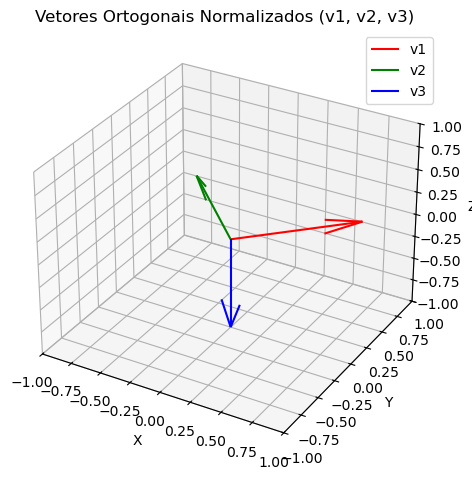

Ângulo entre v1 e v2: 90.0
Ângulo entre v1 e v3: 90.0
Ângulo entre v2 e v3: 90.0


In [41]:

v1 = np.array([1, 1, 0])
v2 = np.array([-1, 1, 0])
v3 = np.array([0, 0, -1])


v1_unit = v1 / np.linalg.norm(v1)
v2_unit = v2 / np.linalg.norm(v2)
v3_unit = v3 / np.linalg.norm(v3)


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


origin = np.zeros(3)


ax.quiver(*origin, *v1_unit, color='r', label='v1', length=1)
ax.quiver(*origin, *v2_unit, color='g', label='v2', length=1)
ax.quiver(*origin, *v3_unit, color='b', label='v3', length=1)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Vetores Ortogonais Normalizados (v1, v2, v3)')
ax.legend()

plt.tight_layout()
plt.show()

print("Ângulo entre v1 e v2:", angular_distance(v1, v2))  # 90.0
print("Ângulo entre v1 e v3:", angular_distance(v1, v3))  # 90.0
print("Ângulo entre v2 e v3:", angular_distance(v2, v3))  # 90.0


In [42]:
sph_lat = 30
geod_lat = 22
v1_geod = spherical_to_geodetic(sph_lat,geod_lat, 1, 1,0)
v2_geod = spherical_to_geodetic(sph_lat,geod_lat,-1, 1,0)
v3_geod = spherical_to_geodetic(sph_lat,geod_lat,0, 0,-1)

print("Ângulo entre v1 e v2:", angular_distance(v1_geod, v2_geod))  # 90.0
print("Ângulo entre v1 e v3:", angular_distance(v1_geod, v3_geod))  # 90.0
print("Ângulo entre v2 e v3:", angular_distance(v2_geod, v3_geod))  # 90.0


Ângulo entre v1 e v2: 90.0
Ângulo entre v1 e v3: 90.0
Ângulo entre v2 e v3: 90.0
